Cel: Przewidywanie przychodu (Revenue) z pojedynczej transakcji.

Dlaczego to? Ponieważ pozwala to firmie planować budżet i zapasy magazynowe.
Twoje zadanie ML:Zmienna celu (Target): Revenue (Wartość sprzedaży).Cechy (Features): Brand, Product_Category, Country, Sales_Channel, Month (wyciągnięty z daty), Price_Point.Algorytm: Zacznij od prostego Random Forest Regressor lub XGBoost. Są świetne do danych tabelarycznych.Pytanie, na które odpowie model: > "Jeśli wprowadzimy nową markę X do kategorii 'Skin Care' w Niemczech przez kanał online w grudniu, jakiego przychodu możemy się spodziewać?"

In [1]:
import pandas as pd 
import optuna
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
df = pd.read_csv('data_for_model.csv', index_col='Date', parse_dates=True)

In [3]:
df['Month'] = df.index.month

<Axes: ylabel='Revenue_USD'>

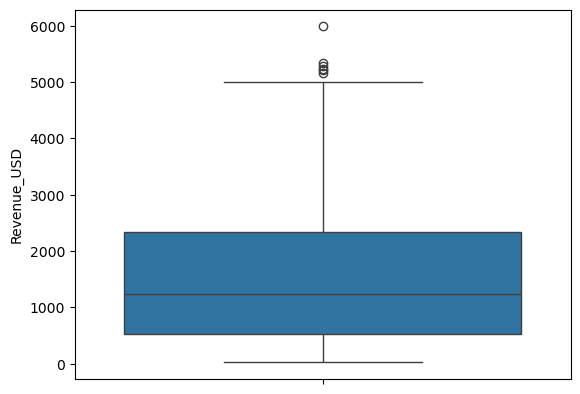

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data= df['Revenue_USD'])
plt.title('Revenue_outliers')
plt.show()

In [4]:
Q1 = df['Revenue_USD'].quantile(0.25)
Q3 = df['Revenue_USD'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Revenue_USD'] >= lower_bound) & (df['Revenue_USD'] <= upper_bound)]

In [5]:
cols_to_drop = ['Revenue_USD', 'Units_Sold', 'Sale_ID']
target = 'Revenue_USD'
X = df.drop(columns= cols_to_drop)
y = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size = 0.2)

In [7]:
num_col = X.select_dtypes(include='number').columns
cat_col = X.select_dtypes(include='object').columns

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_15180\4292161370.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = X.select_dtypes(include='object').columns


In [8]:
num_proccesor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [9]:
cat_proccesor = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('OneHotEncoder', OneHotEncoder())
])

In [10]:
preproccesor = ColumnTransformer([
    ('num_procesor', num_proccesor, num_col),
    ('cat_procesor', cat_proccesor, cat_col)
])

In [11]:
model = RandomForestRegressor(random_state=42)

In [12]:
pipeline = Pipeline([
    ('procesowanie', preproccesor),
    ('model', model)
])

In [13]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Błąd średni (MAE): {mae:.2f} USD")
print(f"Błąd pierwiastkowy (RMSE): {rmse:.2f} USD")
print(f"Skuteczność (R2): {r2:.2f}")

Błąd średni (MAE): 677.33 USD
Błąd pierwiastkowy (RMSE): 944.08 USD
Skuteczność (R2): 0.33


In [28]:
def objective(trial):
    
    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 20, 120),
        'model__max_depth': trial.suggest_int('model__max_depth', 5, 20),
        'model__min_samples_split': trial.suggest_int('model__min_samples_split', 2, 10),
        'model__min_samples_leaf': trial.suggest_int('model__min_samples_leaf', 1, 10),
    }

    pipeline.set_params(**params)

    
    pipeline.fit(X_train, y_train)

    
    y_pred = pipeline.predict(X_test)

    
    mae = mean_absolute_error(y_test, y_pred)

    return mae

    

In [ ]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20, show_progress_bar=True)


[I 2026-04-01 19:21:53,257] A new study created in memory with name: no-name-cd0306da-d1b8-4034-ba17-51fe7d0a3887


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-01 19:21:53,343] Trial 0 finished with value: 685.3238916735796 and parameters: {'model__n_estimators': 43, 'model__max_depth': 7, 'model__min_samples_split': 6, 'model__min_samples_leaf': 4}. Best is trial 0 with value: 685.3238916735796.
[I 2026-04-01 19:21:53,423] Trial 1 finished with value: 679.4517351833979 and parameters: {'model__n_estimators': 66, 'model__max_depth': 18, 'model__min_samples_split': 9, 'model__min_samples_leaf': 10}. Best is trial 1 with value: 679.4517351833979.
[I 2026-04-01 19:21:53,632] Trial 2 finished with value: 679.0976254372694 and parameters: {'model__n_estimators': 90, 'model__max_depth': 9, 'model__min_samples_split': 3, 'model__min_samples_leaf': 1}. Best is trial 2 with value: 679.0976254372694.
[I 2026-04-01 19:21:53,709] Trial 3 finished with value: 687.0797009546292 and parameters: {'model__n_estimators': 55, 'model__max_depth': 13, 'model__min_samples_split': 10, 'model__min_samples_leaf': 8}. Best is trial 2 with value: 679.0976254

In [30]:
print("Best trial:", study.best_trial)
print("Best hyperparameters:", study.best_params)

Best trial: FrozenTrial(number=18, state=<TrialState.COMPLETE: 1>, values=[666.0621878373129], datetime_start=datetime.datetime(2026, 4, 1, 19, 21, 55, 733929), datetime_complete=datetime.datetime(2026, 4, 1, 19, 21, 55, 850778), params={'model__n_estimators': 77, 'model__max_depth': 10, 'model__min_samples_split': 4, 'model__min_samples_leaf': 4}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'model__n_estimators': IntDistribution(high=120, log=False, low=20, step=1), 'model__max_depth': IntDistribution(high=20, log=False, low=5, step=1), 'model__min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'model__min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1)}, trial_id=18, value=None)
Best hyperparameters: {'model__n_estimators': 77, 'model__max_depth': 10, 'model__min_samples_split': 4, 'model__min_samples_leaf': 4}


In [31]:
pipeline.set_params(**study.best_params)

# Ostateczny trening na najlepszych ustawieniach
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [32]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Błąd średni (MAE): {mae:.2f} USD")
print(f"Błąd pierwiastkowy (RMSE): {rmse:.2f} USD")
print(f"Skuteczność (R2): {r2:.2f}")

Błąd średni (MAE): 666.06 USD
Błąd pierwiastkowy (RMSE): 917.99 USD
Skuteczność (R2): 0.37


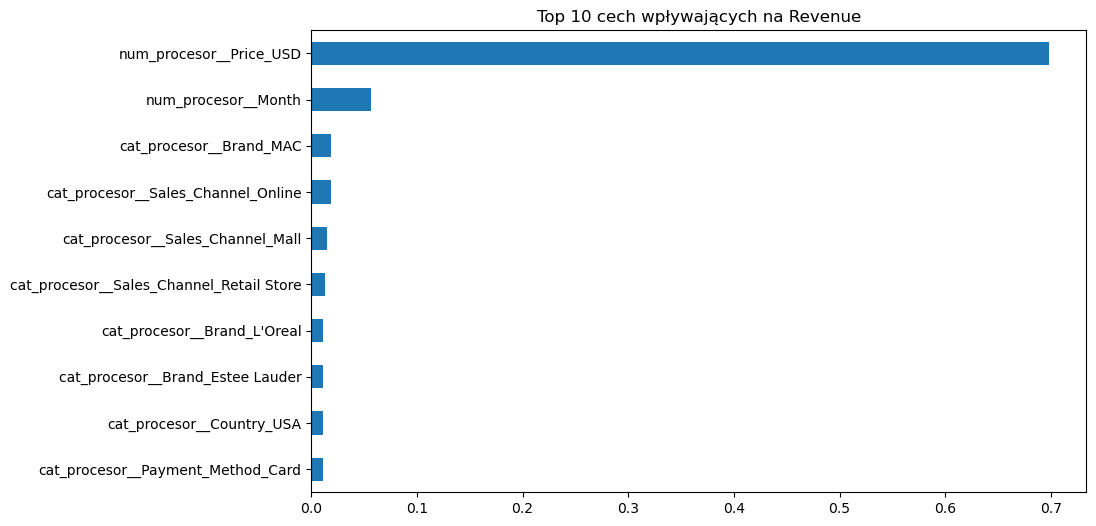

In [33]:
importances = pipeline.named_steps['model'].feature_importances_
features = pipeline.named_steps['procesowanie'].get_feature_names_out()

# Tworzymy prosty wykres top 10 cech
plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values().tail(10).plot(kind='barh')
plt.title("Top 10 cech wpływających na Revenue")
plt.show()